<h1>Ecole Polytechnique de Thies</h1>
<h2>Département du Génie Informatique et Télécommunications<br/>
DIC 1<br/>
2023/2024</h2>
<p>
<h1>Thierno Daouda LY</h1>
</p>

<h1>Apprentissage automatique Descente de Gradient, Classement et Régression<h1>

<h1> Exercice 1: Regression linéaire, equation normale<h1>
<p>
La régression linéaire est un algorithme d’apprentissage supervisé de type régression. Les algorithmes de régression permettent de prédire des valeurs continues à partir des variables prédictives. Le principe est de trouver une droite qui se rapproche le plus possible d’un ensemble de points (points d’entraînement).
</p>
<p>
Considérons l’équation de prédiction d’un modèle de régression linéaire suivante:

$$
\widehat{y} = h_θ(x) = θ^T.x= θ_0+ θ_1x_1 +…+θ_nx_n\tag{1,1}
$$

où $θ=\begin{bmatrix}θ_0 \\θ_1 \\ \vdots \\θ_n \end{bmatrix}$ est le vecteur des paramètres du modèle, $θ^T$ transposé de θ, x vecteur des valeurs d’une observation, $θ^T.x$ est le produit scalaire de $θ^T$ et x et $h_θ$ est la fonction hypothèse utilisant les paramètres θ.
</p>

<p>
Pour la suite nous allons considerer une fonction affine univariée eq[1.2] puis y ajouter du bruit et determiner le model de regression
$$
f(x)=4+3x\tag{1,2}
$$


1. Generation des donnees d'entrainement

le module random contient une fonction $random()$ permettant de generer un nombre aleatoire dans l'intervalle $[0,1[$

1.1. Generons un nombre $xMin$ aleatoire compris entre -10 et 2 qui sera notre $x$ minimum et un nombre $deltaX$ entre 10 et 20 qui sera la distance maximale entre deux x. On a $xMax=xMin+deltaX$



In [ ]:
import random

#generer de maniere aleatoire un entier xMin dans [-10, 2]
xMin = random.randint(-10,2)

#generer deltaX la largeur de l'intervalle compris entre 10 et 20
deltaX = random.randint(10,20)

#Deduction de xMax
xMax = xMin + deltaX

#affichage variables xMin, deltaX, xMax
print(f"xMin = {xMin}")
print(f"deltaX = {deltaX}")
print(f"xMax = {xMax}")

xMin = -5
deltaX = 13
xMax = 8


1-2 Vecteur x d'entrainement

La fonction latex $np.random.rand(n,m)$ de la librairie numpy permet de generer une matrice aleatoire de n lignes et m colonnes. (Voir la documentation numpy)

Generons un vecteur aleatoire $x$ de dimension 20 dont les elements $x_i$ sont entre xMin et xMax



In [ ]:
#générer x  avec des elements appartenant a l'intervalle [xMin, xMax]
import numpy as np

x = np.random.rand(20) * (xMax - xMin) + xMin

#affichage de X
print(F"X = {x}")
#affichage de la dimension de x
print("shape : ",x.shape)

X = [ 3.12092492  3.51175009  6.20366665 -1.0056551   1.17676428  1.5769692
 -0.45260447 -3.96020665  7.73176473 -3.61409373  0.79684194  4.90373084
 -1.89102135  4.56309641  1.18389204  2.73381631 -1.12686528  5.91265461
 -0.14917984  3.14694262]
shape :  (20,)


1.3. Calculons F=f(X) f etant la fonction definie en (1,2)

In [ ]:
#calculer F
F = 4 + 3 * x
#affichage de la valeur de f
print(F"F={F}")

F=[13.36277475 14.53525028 22.61099995  0.9830347   7.53029283  8.7309076
  2.64218659 -7.88061995 27.19529419 -6.84228118  6.39052581 18.71119252
 -1.67306406 17.68928924  7.55167613 12.20144893  0.61940417 21.73796382
  3.55246047 13.44082787]


1.4. Pour determiner Y on va prendre $F$ et y ajouter du bruit gaussien. Puis on va afficher y et f(x) pour visualiser les données.


Le resultat donne une figure qui ressemble à l'image suivante


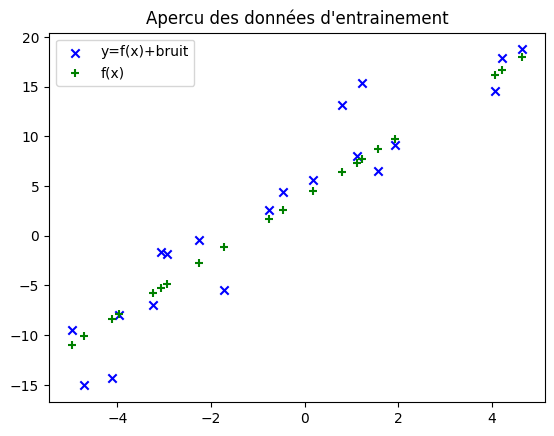


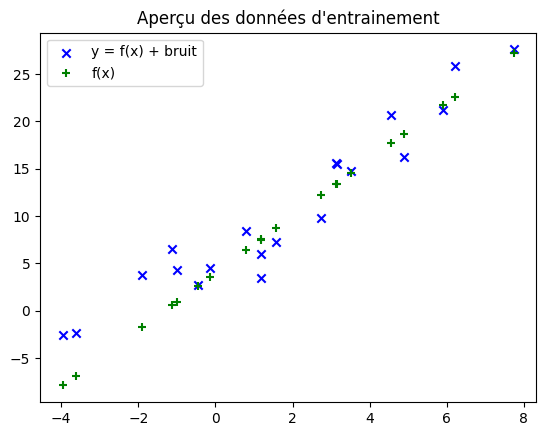

In [ ]:
import matplotlib.pyplot as plt

#ajout du bruit a F
Y = F + np.random.normal(0,3,len(x))

#Visualisation des donnees
plt.scatter(x, Y, marker='x', color='b', label='Y')
plt.scatter(x, F, marker='+', color='g', label='F')
plt.title("Aperçu des données d'entrainement")
plt.legend(['y = f(x) + bruit', 'f(x)'])
plt.show()

La courbe obtenue montre une comparaison visuelle entre les données d'entraînement originales \( f(x) \) et les données bruitées \( y \). L'ajout de bruit aux données \( f(x) \) les rend plus dispersées autour de la fonction originale, ce qui peut rendre l'identification de tendances plus difficile. Cela met en évidence l'importance de prendre en compte le bruit lors de l'analyse et de la modélisation des données, ainsi que la nécessité de techniques robustes pour traiter les données bruitées.

2. Regression lineaire

2.1. L’équation de régression lorsque les entrées sont composées d’une seule valeur x est donnée par

$$
\widehat{y}_i = θ_0 + θ_1x_i = [1, x_i]\begin{bmatrix}θ_0 \\θ_1 \end{bmatrix}
$$

posons $X$ la matrice 2 deux colonnes dont les elements de la premiere colonne ont comme valeur 1 et $x_i$ l'element de la deuxieme colonne à la ligne $i$, $\widehat{Y}$ le vecteur constitue par les $\widehat{y}_i$

On a alors

$\widehat{Y}=h_θ(X) = Xθ$

l'erreur quadratique moyenne peux se calculer par :

$E=\sum_{i=1}^N{(y-y_i)^2} $

Calculons les erreurs quadratiques $E_1, E_2, E_3$ pour $θ$ egale aux valeurs successives suivantes:  $theta1=\begin{bmatrix}3 \\7/2 \end{bmatrix}$,
 $theta2=\begin{bmatrix}5 \\5/2 \end{bmatrix}$ et $theta3 \begin{bmatrix}4 \\3 \end{bmatrix}$




In [ ]:
# Calculer X,  la premiere colonne ayant des valeurs egale à 1 et
# la deuxieme colonne etant les x_i vous pouvez utiliser les fonctions numpy
# np.ones(var) et np.c_[a,b]
X = np.c_[np.ones(len(x)), x]

# Définition des valeurs de theta
theta1 = np.array([3, 7/2])
theta2 = np.array([5, 5/2])
theta3 = np.array([4, 3])

# Calcul des erreurs quadratiques et des predictions

Y1 = np.dot(X, theta1)
E1 = np.sum((Y - Y1) ** 2)

Y2 = np.dot(X, theta2)
E2 = np.sum((Y - Y2) ** 2)

Y3 = np.dot(X, theta3)
E3 = np.sum((Y - Y3) ** 2)

#affichage des erreurs quadratique
print(F"E1 = {E1}")
print(F"E2 = {E2}")
print(F"E3 = {E3}")



E1 = 329.35863841795634
E2 = 152.7956260972134
E3 = 190.87020944247809


2.2. Parmis $θ_1$, $θ_2$ et $θ_3$ quel est le meilleur model

2.3 Creer une figure y placer les points (x<sub>i</sub>,y<sub>i</sub>)

2.4 Pour chaque model θ predire la valeur yMin de xMin et la valeur yMax de xMax

2.5 Pour chaque θ tracer la prediction des x qui sont sur l'intervalle delimitee par les points (xMin, yMin) et (xMax, yMax) (c'est le segment delimité par les points (xMin, yMin) et (xMax, yMax).)

Vous aurez une figure qui ressemble à la figure ci dessous

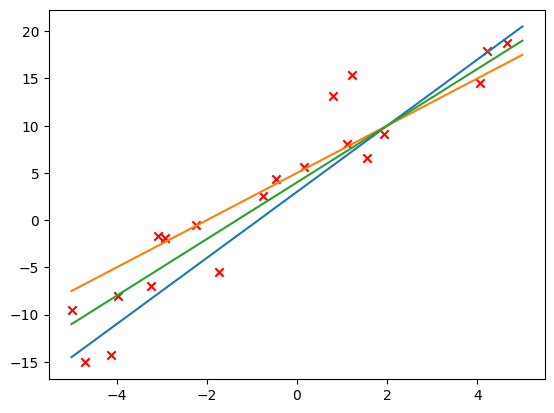



Le meilleur modèle est Theta2 avec theta = [5.  2.5]

.


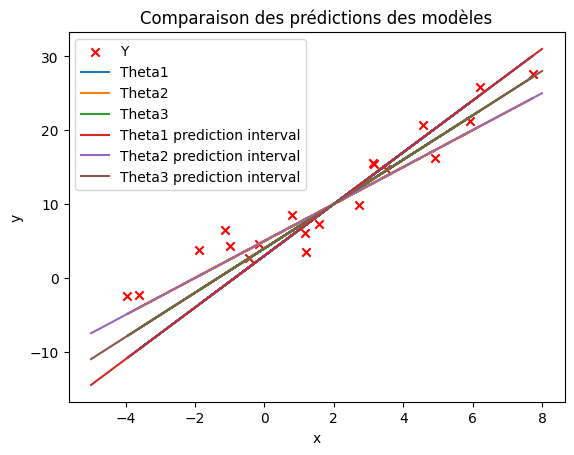

In [ ]:
import matplotlib.pyplot as plt

# affichage des points xi, yi
plt.scatter(x, Y, marker='x', color='r', label='Y')

# afficher des prédictions pour les modèles theta1, theta2 et theta3
plt.plot(x, np.dot(X, theta1), label='Theta1')
plt.plot(x, np.dot(X, theta2), label='Theta2')
plt.plot(x, np.dot(X, theta3), label='Theta3')

# Détermination du meilleur modèle
errors = [E1, E2, E3]
best_model_idx = np.argmin(errors)
best_model = [theta1, theta2, theta3][best_model_idx]
best_model_label = ['Theta1', 'Theta2', 'Theta3'][best_model_idx]
print(f"Le meilleur modèle est {best_model_label} avec theta = {best_model}\n\n.")

# Prédictions de yMin et yMax pour chaque modèle
yMin_theta1 = np.dot(np.array([1, xMin]), theta1)
yMax_theta1 = np.dot(np.array([1, xMax]), theta1)

yMin_theta2 = np.dot(np.array([1, xMin]), theta2)
yMax_theta2 = np.dot(np.array([1, xMax]), theta2)

yMin_theta3 = np.dot(np.array([1, xMin]), theta3)
yMax_theta3 = np.dot(np.array([1, xMax]), theta3)

# Tracé des segments pour chaque modèle
plt.plot([xMin, xMax], [yMin_theta1, yMax_theta1], label='Theta1 prediction interval')
plt.plot([xMin, xMax], [yMin_theta2, yMax_theta2], label='Theta2 prediction interval')
plt.plot([xMin, xMax], [yMin_theta3, yMax_theta3], label='Theta3 prediction interval')

# Affichage de la légende
plt.legend()

plt.xlabel("x")
plt.ylabel("y")

plt.title("Comparaison des prédictions des modèles")

plt.show()


3. Solution optimale : Equation normale

La solution analytique θ qui minimise la fonction coût est donnée par l’équation normale suivante:
$$
\widehat{θ}=(X^T.X)^{-1}.X^T.y
$$

3.1. Calculer $\widehat{θ}$

3.2. Placer les points (x<sub>i</sub>, y<sub>i</sub>)

3.3. En utilisant la solution analytique, tracer la prediction des x  qui sont sur l'intervalle delimitee par les points (xMin, yMin) et (xMax, yMax) (c'est le segment delimité par les points (xMin, yMin) et (xMax, yMax).)

le resultat resultat ressemblera a la figure suivante

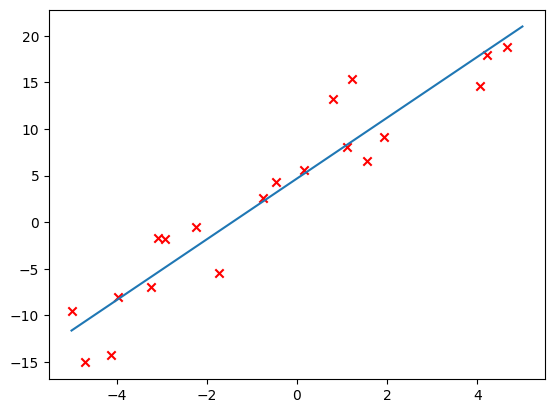

 La valeur de Ô est thetaBest = [6.01312159 2.59413206]





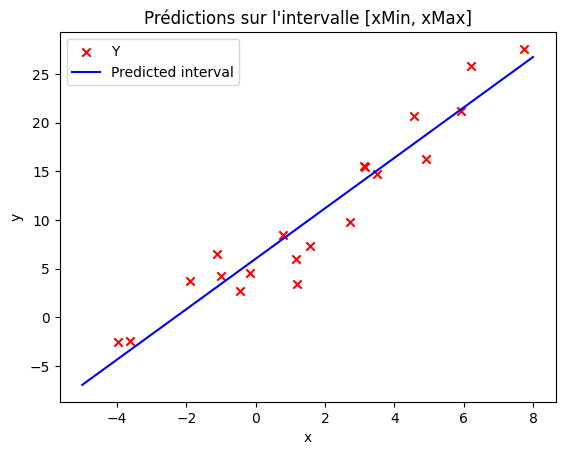

In [ ]:
import numpy as np

# Calcul de theta chapeau (thetaBest)
thetaBest = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)
print(" La valeur de Ô est thetaBest =", thetaBest)
print('\n\n')

# placement des points xi, yi
plt.scatter(x, Y, marker='x', color='r', label='Y')

# tracer les prédictions des points x sur [xMin, xMax]
X_interval = np.array([[1, xMin], [1, xMax]])  # Matrice des intervalles
Y_interval = X_interval.dot(thetaBest)  # Prédictions pour l'intervalle
plt.plot([xMin, xMax], Y_interval, color='b', label='Predicted interval')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Prédictions sur l'intervalle [xMin, xMax]")
plt.legend()
plt.show()


La ligne bleue represente les predictions du modele sur l'intervale [xmin,x max]. Idéalement, on voudrait que les points rouges soient alignés le long de cette ligne, ce qui signifierait que les prédictions du modèle correspondent parfaitement aux données observées. Cependant, étant donné la présence de bruit dans les données, il est naturel de voir une certaine dispersion autour de la ligne de prédiction.

<h1>Exercice 2 : importance de la vectorisation</h1>

Le produit scalaire d'un vecteur-ligne x<sup>T</sup> par un vecteur-colonne y est donné par la formule suivante :
$$
x^Ty=\begin{bmatrix}x_1 x_2 \dots x_n\end{bmatrix}\begin{bmatrix}y_1 \\y_2 \\ \vdots \\y_n \end{bmatrix}=x_1y_1+x_2y_2+\dots+x_ny_n=\sum_{i=1}^nx_iy_i
$$

Le produit de la matrice A (n × m) par la matrice B (m × p) est la matrice C (n × p) telle que l'élément $C_{ij}$(ligne i, colonne j)  est égal au produit scalaire de la ligne i de la matrice A par la colonne j de la matrice B

$$
C_{ij}=\sum_{k=1}^nA_{ik}B_{kj}
$$

1. Creeons une fonction permettant de calculer le produit de deux matrices en utilisant des boucles

In [ ]:
#produit de matrice utilisant une boucle
def product_loop(A, B):
    # Vérification des dimensions des matrices
    if len(A[0]) != len(B):
        raise ValueError("Le nombre de colonnes de la matrice A doit être égal au nombre de lignes de la matrice B")

    # Initialisation de la matrice résultat
    n = len(A)
    m = len(A[0])
    p = len(B[0])
    resultat = [[0] * p for _ in range(n)]

    # Calcul du produit de matrices
    for i in range(n):
        for j in range(p):
            for k in range(m):
                resultat[i][j] += A[i][k] * B[k][j]

    return resultat

2. Creons une fonction permettant de calculer le produit de deux matrice en utilisant la fonction dot de numpy

In [ ]:
#produit de matrice utilisant une vectorisation numpy
import numpy as np
def product_numpy(A, B):
    return np.dot(A, B)

3. Calculons le temps de calcule de produit de matrices carrees dont les dimension sont successivement 10, 100, 1000, .., 10000000
vous pouvez utiliser le module $time$ de python pour determiner les temps de calcul. Les matrices peuvent etre generees de maniere aleatoire avec numpy

In [ ]:
### comparer les temps de calcul pour des matrices carrées de taille 10, 100, 1000, .., 10000000
import numpy as np
import time

def calculate_product_time(matrix_size):
    # Génération de deux matrices aléatoires de taille matrix_size x matrix_size
    A = np.random.rand(matrix_size, matrix_size)
    B = np.random.rand(matrix_size, matrix_size)

    # Mesure du temps de calcul
    start_time = time.time()
    np.dot(A, B)
    end_time = time.time()

    return end_time - start_time

# Dimensions des matrices à tester
matrix_sizes = [10**i for i in range(1, 5)]

# Calcul des temps de calcul pour chaque dimension
for size in matrix_sizes:
    print(f"Dimension de la matrice : {size} x {size}")
    time_taken = calculate_product_time(size)
    print(f"Temps de calcul : {time_taken} secondes\n")

Dimension de la matrice : 10 x 10
Temps de calcul : 4.792213439941406e-05 secondes

Dimension de la matrice : 100 x 100
Temps de calcul : 0.004395723342895508 secondes

Dimension de la matrice : 1000 x 1000
Temps de calcul : 0.0668637752532959 secondes

Dimension de la matrice : 10000 x 10000
Temps de calcul : 66.58865094184875 secondes



On observe que le temps de calcul augmente considérablement à mesure que la taille de la matrice augmente. Cela est dû au fait que le nombre d'opérations nécessaires pour calculer le produit de matrices augmente de manière quadratique avec la taille de la matrice.

4. Traçons la courbe de la difference de temps en fonction de la taille de la matrice

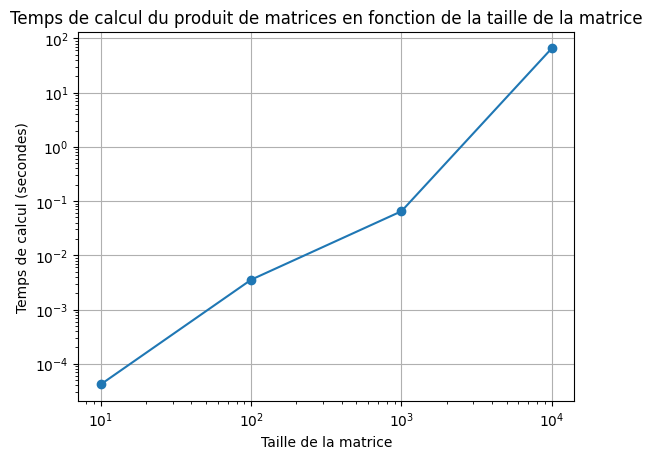

In [ ]:
#tracer la courbe
import matplotlib.pyplot as plt
times = [calculate_product_time(size) for size in matrix_sizes]
plt.plot(matrix_sizes, times, marker='o', linestyle='-')
plt.xlabel('Taille de la matrice')
plt.ylabel('Temps de calcul (secondes)')
plt.title('Temps de calcul du produit de matrices en fonction de la taille de la matrice')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

On remarque que le temps de calcul augmente rapidement avec la taille de la matrice. Cela confirme la complexité temporelle quadratique de l'opération de produit de matrices, ce qui signifie que le temps de calcul augmente quadratiquement avec la taille de la matrice.

Voir autre fichier

#### NB : Pour la question 3, le noyau s'interrompt au delà de la dimension 4 (matrix_sizes = [10**i for i in range(1, 5)]) au lieu d'aller jusqu'à 8. Raison pour laquelle nous nous sommes limités à cette dimension.

5. Vectoriser au max la solution de l'exercice 1 dans un autre fichier notebook (voir autre fichier)